# 17e Quantitative CAM metrics: Base vs HA, last block vs block -4

This notebook runs and analyzes quantitative CAM metrics for the normal 7 class HAM10000 setting.

Goal:

Compare whether choosing an intermediate transformer block improves CAM quality.

Experiments:

1. Base CE, last block
2. Base CE, block -4
3. HA 0.75, last block
4. HA 0.75, block -4

Main question:

Does block -4 give better lesion alignment and/or faithfulness than the final block?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

QUAL_SEED = 42
NUM_SAMPLES = 100
TOPK_COMPARE = 3

REPO_ROOT = Path("..").resolve()

METRICS_ROOT = REPO_ROOT / "external" / "metrics2"

RESULTS = {
    "Base CE last": METRICS_ROOT / f"metrics_base_last_{NUM_SAMPLES}_topk{TOPK_COMPARE}",
    "Base CE block -4": METRICS_ROOT / f"metrics_base_block4_{NUM_SAMPLES}_topk{TOPK_COMPARE}",
    "HA 0.75 last": METRICS_ROOT / f"metrics_ha075_last_{NUM_SAMPLES}_topk{TOPK_COMPARE}",
    "HA 0.75 block -4": METRICS_ROOT / f"metrics_ha075_block4_{NUM_SAMPLES}_topk{TOPK_COMPARE}",
}

print("REPO_ROOT:", REPO_ROOT)
print("METRICS_ROOT:", METRICS_ROOT)

for name, folder in RESULTS.items():
    print(name, "->", folder)
    if not folder.exists():
        print("  [WARN] missing folder")

REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis
METRICS_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis/external/metrics2
Base CE last -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/metrics2/metrics_base_last_100_topk3
Base CE block -4 -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/metrics2/metrics_base_block4_100_topk3
HA 0.75 last -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/metrics2/metrics_ha075_last_100_topk3
HA 0.75 block -4 -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/metrics2/metrics_ha075_block4_100_topk3


In [2]:
def load_result_set(name, folder):
    folder = Path(folder)

    per_sample_candidates = sorted(folder.glob("per_sample_metrics__*.csv"))
    summary_candidates = sorted(folder.glob("per_method_summary__*.csv"))

    if len(per_sample_candidates) == 0:
        raise FileNotFoundError(f"{name}: no per_sample_metrics__*.csv found in {folder}")
    if len(summary_candidates) == 0:
        raise FileNotFoundError(f"{name}: no per_method_summary__*.csv found in {folder}")

    if len(per_sample_candidates) > 1:
        print(f"[warn] {name}: found multiple per-sample files. Using newest:")
        for p in per_sample_candidates:
            print("  ", p.name)

    if len(summary_candidates) > 1:
        print(f"[warn] {name}: found multiple summary files. Using newest:")
        for p in summary_candidates:
            print("  ", p.name)

    per_sample_path = max(per_sample_candidates, key=lambda p: p.stat().st_mtime)
    summary_path = max(summary_candidates, key=lambda p: p.stat().st_mtime)

    per_sample = pd.read_csv(per_sample_path)
    summary = pd.read_csv(summary_path)

    per_sample["experiment"] = name
    summary["experiment"] = name
    per_sample["source_file"] = per_sample_path.name
    summary["source_file"] = summary_path.name

    return per_sample, summary


def mean_std_str(mean, std, digits=3):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

In [3]:
all_per_sample = []
all_summary = []

for name, folder in RESULTS.items():
    try:
        per_sample, summary = load_result_set(name, folder)
        all_per_sample.append(per_sample)
        all_summary.append(summary)
        print(f"Loaded: {name}")
    except Exception as e:
        print(f"[skip] {name}: {e}")

if len(all_per_sample) == 0:
    raise RuntimeError("No experiment outputs were loaded.")

all_per_sample = pd.concat(all_per_sample, ignore_index=True)
all_summary = pd.concat(all_summary, ignore_index=True)

print("\nPer-sample shape:", all_per_sample.shape)
print("Summary shape:", all_summary.shape)

print("\nExperiments loaded:")
print(all_per_sample["experiment"].value_counts())

print("\nMethods loaded:")
print(all_per_sample["method"].value_counts())

print("\nPer-sample columns:")
print(all_per_sample.columns.tolist())

display(all_per_sample.head())
display(all_summary.head())

Loaded: Base CE last
Loaded: Base CE block -4
Loaded: HA 0.75 last
Loaded: HA 0.75 block -4

Per-sample shape: (1600, 34)
Summary shape: (16, 30)

Experiments loaded:
experiment
Base CE last        400
Base CE block -4    400
HA 0.75 last        400
HA 0.75 block -4    400
Name: count, dtype: int64

Methods loaded:
method
gradcam_target       400
gradcam_reference    400
gradcam_diff         400
finercam             400
Name: count, dtype: int64

Per-sample columns:
['image_id', 'image', 'gt_idx', 'gt_name', 'pred_idx', 'pred_name', 'pred_prob', 'target_idx', 'target_name', 'target_prob', 'reference_idx', 'reference_name', 'reference_prob', 'comparison_categories', 'method', 'compare_mode', 'compare_tag', 'rel_conf_original_target_confidence', 'rel_conf_original_reference_confidence', 'rel_conf_average_target_drop', 'rel_conf_average_reference_drop', 'rel_conf_average_relative_confidence_drop', 'rel_conf_max_relative_confidence_drop', 'del_original_confidence', 'del_auc', 'ins_original

,image_id,image,gt_idx,gt_name,pred_idx,pred_name,pred_prob,target_idx,target_name,target_prob,reference_idx,reference_name,reference_prob,comparison_categories,method,compare_mode,compare_tag,rel_conf_original_target_confidence,rel_conf_original_reference_confidence,rel_conf_average_target_drop,rel_conf_average_reference_drop,rel_conf_average_relative_confidence_drop,rel_conf_max_relative_confidence_drop,del_original_confidence,del_auc,ins_original_confidence,ins_auc,mask_dice,mask_iou,mask_energy_inside,mask_pointing_game,mask_area_fraction,experiment,source_file
0,ISIC_0032343,images/ISIC_0032343.jpg,2,BKL,2,BKL,0.996267,2,BKL,0.996267,4,MEL,0.002995,"[4, 5, 0]",gradcam_target,gt_topk_non_target,gt_topk_k3,0.996267,0.001221,0.029675,-0.009856,0.039531,0.039531,0.996267,0.745541,0.996267,0.904560,1.504004e-01,8.131509e-02,0.287703,0.0,0.346580,Base CE last,per_sample_metrics__gt_topk_k3.csv
1,ISIC_0032343,images/ISIC_0032343.jpg,2,BKL,2,BKL,0.996267,2,BKL,0.996267,4,MEL,0.002995,"[4, 5, 0]",gradcam_reference,gt_topk_non_target,gt_topk_k3,0.996267,0.001221,-0.001736,0.000641,-0.002376,-0.002376,0.996267,0.653757,0.996267,0.900711,5.598164e-03,2.806939e-03,0.505363,0.0,0.346580,Base CE last,per_sample_metrics__gt_topk_k3.csv
2,ISIC_0032343,images/ISIC_0032343.jpg,2,BKL,2,BKL,0.996267,2,BKL,0.996267,4,MEL,0.002995,"[4, 5, 0]",gradcam_diff,gt_topk_non_target,gt_topk_k3,0.996267,0.001221,0.014844,-0.004926,0.019770,0.019770,0.996267,0.766221,0.996267,0.891520,1.296648e-01,6.932703e-02,0.257155,0.0,0.346580,Base CE last,per_sample_metrics__gt_topk_k3.csv
3,ISIC_0032343,images/ISIC_0032343.jpg,2,BKL,2,BKL,0.996267,2,BKL,0.996267,4,MEL,0.002995,"[4, 5, 0]",finercam,gt_topk_non_target,gt_topk_k3,0.996267,0.001221,0.006233,-0.002069,0.008302,0.008302,0.996267,0.786646,0.996267,0.859341,1.268793e-01,6.773684e-02,0.273555,0.0,0.346580,Base CE last,per_sample_metrics__gt_topk_k3.csv
4,ISIC_0024698,images/ISIC_0024698.jpg,5,NV,4,MEL,0.799539,5,NV,0.198369,4,MEL,0.799539,"[4, 2, 6]",gradcam_target,gt_topk_non_target,gt_topk_k3,0.198369,0.267185,-0.092298,0.030770,-0.123067,-0.123067,0.198369,0.500203,0.198369,0.376130,4.864996e-13,4.864996e-13,0.001557,0.0,0.044284,Base CE last,per_sample_metrics__gt_topk_k3.csv


,method,compare_mode,compare_tag,n,rel_conf_target_mean,rel_conf_target_std,rel_conf_reference_mean,rel_conf_reference_std,rel_conf_target_drop_mean,rel_conf_target_drop_std,rel_conf_reference_drop_mean,rel_conf_reference_drop_std,rel_conf_rd_mean,rel_conf_rd_std,del_auc_mean,del_auc_std,ins_auc_mean,ins_auc_std,mask_dice_mean,mask_dice_std,mask_iou_mean,mask_iou_std,mask_energy_inside_mean,mask_energy_inside_std,mask_pointing_game_mean,mask_pointing_game_std,mask_area_fraction_mean,mask_area_fraction_std,experiment,source_file
0,finercam,gt_topk_non_target,gt_topk_k3,100,0.815172,0.300407,0.061504,0.100055,0.077378,0.219064,-0.021920,0.079225,0.099298,0.293744,0.639726,0.237195,0.823143,0.128281,0.099916,0.099688,0.055664,0.059447,0.305969,0.232620,0.33,0.472582,0.353741,0.192306,Base CE last,per_method_summary__gt_topk_k3.csv
1,gradcam_diff,gt_topk_non_target,gt_topk_k3,100,0.815172,0.300407,0.061504,0.100055,0.081208,0.218774,-0.023311,0.080299,0.104519,0.294053,0.520693,0.212221,0.802893,0.152160,0.089689,0.093169,0.049601,0.055045,0.293212,0.245859,0.33,0.472582,0.353741,0.192306,Base CE last,per_method_summary__gt_topk_k3.csv
2,gradcam_reference,gt_topk_non_target,gt_topk_k3,100,0.815172,0.300407,0.061504,0.100055,-0.062623,0.258607,0.022328,0.086987,-0.084951,0.345473,0.644378,0.177373,0.692010,0.236222,0.131604,0.127227,0.075941,0.082015,0.462930,0.238770,0.45,0.500000,0.353741,0.192306,Base CE last,per_method_summary__gt_topk_k3.csv
3,gradcam_target,gt_topk_non_target,gt_topk_k3,100,0.815172,0.300407,0.061504,0.100055,0.076447,0.216063,-0.021873,0.079039,0.098321,0.290167,0.648418,0.234383,0.821855,0.131315,0.109663,0.105618,0.061524,0.063700,0.304104,0.233667,0.34,0.476095,0.353741,0.192306,Base CE last,per_method_summary__gt_topk_k3.csv
4,finercam,gt_topk_non_target,gt_topk_k3,100,0.815172,0.300407,0.061504,0.100055,0.075351,0.230034,-0.017669,0.084527,0.093020,0.306974,0.580251,0.222967,0.819268,0.148325,0.146937,0.137905,0.085789,0.088553,0.429381,0.249138,0.51,0.502418,0.353741,0.192306,Base CE block -4,per_method_summary__gt_topk_k3.csv


In [4]:
IMPORTANT_METRICS = [
    "rel_conf_average_relative_confidence_drop",
    "rel_conf_average_target_drop",
    "del_auc",
    "ins_auc",
    "mask_energy_inside",
    "mask_pointing_game",
    "mask_iou",
    "mask_dice",
]

DISPLAY_NAMES = {
    "rel_conf_average_relative_confidence_drop": "RD ↑",
    "rel_conf_average_target_drop": "Target drop ↑",
    "del_auc": "Deletion AUC ↓",
    "ins_auc": "Insertion AUC ↑",
    "mask_energy_inside": "Energy inside lesion ↑",
    "mask_pointing_game": "Pointing game ↑",
    "mask_iou": "Mask IoU ↑",
    "mask_dice": "Mask Dice ↑",
}

LOWER_IS_BETTER = {
    "del_auc",
}

METHOD_ORDER = [
    "gradcam_target",
    "gradcam_reference",
    "gradcam_diff",
    "finercam",
]


def summarize_from_per_sample(per_sample_df):
    available_metrics = [m for m in IMPORTANT_METRICS if m in per_sample_df.columns]

    agg_dict = {
        "n": ("image_id", "count"),
    }

    for m in available_metrics:
        agg_dict[f"{m}_mean"] = (m, "mean")
        agg_dict[f"{m}_std"] = (m, "std")

    out = (
        per_sample_df
        .groupby(["experiment", "method"], dropna=False)
        .agg(**agg_dict)
        .reset_index()
    )

    return out


compact_summary = summarize_from_per_sample(all_per_sample)

compact_summary["method"] = pd.Categorical(
    compact_summary["method"].astype(str),
    categories=METHOD_ORDER,
    ordered=True,
)

experiment_order = [
    "Base CE last",
    "Base CE block -4",
    "HA 0.75 last",
    "HA 0.75 block -4",
]

compact_summary["experiment"] = pd.Categorical(
    compact_summary["experiment"].astype(str),
    categories=experiment_order,
    ordered=True,
)

compact_summary = compact_summary.sort_values(["experiment", "method"]).reset_index(drop=True)

display(compact_summary)

,experiment,method,n,rel_conf_average_relative_confidence_drop_mean,rel_conf_average_relative_confidence_drop_std,rel_conf_average_target_drop_mean,rel_conf_average_target_drop_std,del_auc_mean,del_auc_std,ins_auc_mean,ins_auc_std,mask_energy_inside_mean,mask_energy_inside_std,mask_pointing_game_mean,mask_pointing_game_std,mask_iou_mean,mask_iou_std,mask_dice_mean,mask_dice_std
0,Base CE last,gradcam_target,100,0.098321,0.290167,0.076447,0.216063,0.648418,0.234383,0.821855,0.131315,0.304104,0.233667,0.34,0.476095,0.061524,0.063700,0.109663,0.105618
1,Base CE last,gradcam_reference,100,-0.084951,0.345473,-0.062623,0.258607,0.644378,0.177373,0.692010,0.236222,0.462930,0.238770,0.45,0.500000,0.075941,0.082015,0.131604,0.127227
2,Base CE last,gradcam_diff,100,0.104519,0.294053,0.081208,0.218774,0.520693,0.212221,0.802893,0.152160,0.293212,0.245859,0.33,0.472582,0.049601,0.055045,0.089689,0.093169
3,Base CE last,finercam,100,0.099298,0.293744,0.077378,0.219064,0.639726,0.237195,0.823143,0.128281,0.305969,0.232620,0.33,0.472582,0.055664,0.059447,0.099916,0.099688
4,Base CE block -4,gradcam_target,100,0.095388,0.327781,0.075958,0.243500,0.576979,0.223071,0.818317,0.153207,0.438844,0.253792,0.47,0.501614,0.081757,0.086662,0.140529,0.134618
5,Base CE block -4,gradcam_reference,100,-0.060043,0.261835,-0.044458,0.196834,0.721520,0.170898,0.679628,0.207351,0.318309,0.220597,0.27,0.446196,0.056589,0.075368,0.098670,0.120121
6,Base CE block -4,gradcam_diff,100,0.077198,0.321044,0.060837,0.239872,0.403197,0.177304,0.800847,0.190407,0.449005,0.271200,0.47,0.501614,0.071840,0.080956,0.124628,0.126653
7,Base CE block -4,finercam,100,0.093020,0.306974,0.075351,0.230034,0.580251,0.222967,0.819268,0.148325,0.429381,0.249138,0.51,0.502418,0.085789,0.088553,0.146937,0.137905
8,HA 0.75 last,gradcam_target,100,0.138528,0.288539,0.104105,0.216341,0.528408,0.275657,0.793657,0.163046,0.291296,0.271436,0.30,0.460566,0.094124,0.162534,0.141066,0.212675
9,HA 0.75 last,gradcam_reference,100,-0.146828,0.371477,-0.109917,0.278574,0.596770,0.171335,0.679285,0.255840,0.570987,0.214288,0.54,0.500908,0.243970,0.217123,0.346485,0.266862


In [5]:
MAIN_METHODS = ["gradcam_target", "finercam"]

MAIN_METRICS = [
    "rel_conf_average_relative_confidence_drop",
    "del_auc",
    "mask_energy_inside",
    "mask_pointing_game",
]

MAIN_DISPLAY_NAMES = {
    "rel_conf_average_relative_confidence_drop": "RD ↑",
    "del_auc": "Deletion AUC ↓",
    "mask_energy_inside": "Energy inside lesion ↑",
    "mask_pointing_game": "Pointing game ↑",
}

main_df = compact_summary[
    compact_summary["method"].astype(str).isin(MAIN_METHODS)
].copy()

main_df["method"] = pd.Categorical(
    main_df["method"].astype(str),
    categories=MAIN_METHODS,
    ordered=True,
)

main_df = main_df.sort_values(["experiment", "method"]).reset_index(drop=True)

main_table = pd.DataFrame()
main_table["Experiment"] = main_df["experiment"].astype(str)
main_table["Method"] = main_df["method"].astype(str)
main_table["N"] = main_df["n"].astype(int)

for metric in MAIN_METRICS:
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    if mean_col in main_df.columns:
        main_table[MAIN_DISPLAY_NAMES[metric]] = [
            mean_std_str(mean, std)
            for mean, std in zip(main_df[mean_col], main_df[std_col])
        ]

display(main_table)

,Experiment,Method,N,RD ↑,Deletion AUC ↓,Energy inside lesion ↑,Pointing game ↑
0,Base CE last,gradcam_target,100,0.098 ± 0.290,0.648 ± 0.234,0.304 ± 0.234,0.340 ± 0.476
1,Base CE last,finercam,100,0.099 ± 0.294,0.640 ± 0.237,0.306 ± 0.233,0.330 ± 0.473
2,Base CE block -4,gradcam_target,100,0.095 ± 0.328,0.577 ± 0.223,0.439 ± 0.254,0.470 ± 0.502
3,Base CE block -4,finercam,100,0.093 ± 0.307,0.580 ± 0.223,0.429 ± 0.249,0.510 ± 0.502
4,HA 0.75 last,gradcam_target,100,0.139 ± 0.289,0.528 ± 0.276,0.291 ± 0.271,0.300 ± 0.461
5,HA 0.75 last,finercam,100,0.125 ± 0.276,0.555 ± 0.284,0.231 ± 0.238,0.220 ± 0.416
6,HA 0.75 block -4,gradcam_target,100,0.110 ± 0.317,0.552 ± 0.260,0.431 ± 0.266,0.560 ± 0.499
7,HA 0.75 block -4,finercam,100,0.117 ± 0.304,0.528 ± 0.247,0.455 ± 0.255,0.560 ± 0.499


In [6]:
finercam_df = compact_summary[
    compact_summary["method"].astype(str) == "finercam"
].copy()

cols = [
    "experiment",
    "n",
    "rel_conf_average_relative_confidence_drop_mean",
    "del_auc_mean",
    "mask_energy_inside_mean",
    "mask_pointing_game_mean",
    "mask_dice_mean",
    "mask_iou_mean",
]

cols = [c for c in cols if c in finercam_df.columns]

finercam_table = finercam_df[cols].copy()

finercam_table = finercam_table.rename(columns={
    "experiment": "Experiment",
    "n": "N",
    "rel_conf_average_relative_confidence_drop_mean": "RD ↑",
    "del_auc_mean": "Deletion AUC ↓",
    "mask_energy_inside_mean": "Energy inside lesion ↑",
    "mask_pointing_game_mean": "Pointing game ↑",
    "mask_dice_mean": "Mask Dice ↑",
    "mask_iou_mean": "Mask IoU ↑",
})

display(finercam_table)

,Experiment,N,RD ↑,Deletion AUC ↓,Energy inside lesion ↑,Pointing game ↑,Mask Dice ↑,Mask IoU ↑
3,Base CE last,100,0.099298,0.639726,0.305969,0.33,0.099916,0.055664
7,Base CE block -4,100,0.093020,0.580251,0.429381,0.51,0.146937,0.085789
11,HA 0.75 last,100,0.124542,0.554920,0.230542,0.22,0.089463,0.054862
15,HA 0.75 block -4,100,0.117011,0.527617,0.454550,0.56,0.221758,0.140719


In [7]:
def extract_model_and_block(experiment_name: str):
    exp = str(experiment_name)

    if exp.startswith("Base"):
        model = "Base CE"
    elif exp.startswith("HA"):
        model = "HA 0.75"
    else:
        model = "Unknown"

    if "block -4" in exp:
        block = "-4"
    elif "last" in exp:
        block = "last"
    else:
        block = "unknown"

    return model, block


delta_df = compact_summary.copy()
delta_df[["model_name", "block_name"]] = delta_df["experiment"].astype(str).apply(
    lambda x: pd.Series(extract_model_and_block(x))
)

delta_df = delta_df[delta_df["method"].astype(str) == "finercam"].copy()

metrics_for_delta = [
    "rel_conf_average_relative_confidence_drop_mean",
    "del_auc_mean",
    "mask_energy_inside_mean",
    "mask_pointing_game_mean",
    "mask_dice_mean",
    "mask_iou_mean",
]

rows = []

for model_name in ["Base CE", "HA 0.75"]:
    sub = delta_df[delta_df["model_name"] == model_name].copy()

    last = sub[sub["block_name"] == "last"]
    block4 = sub[sub["block_name"] == "-4"]

    if len(last) == 0 or len(block4) == 0:
        print(f"[skip] missing last or block -4 for {model_name}")
        continue

    last = last.iloc[0]
    block4 = block4.iloc[0]

    row = {
        "Model": model_name,
        "Method": "finercam",
        "N last": int(last["n"]),
        "N block -4": int(block4["n"]),
    }

    readable_metrics = {
        "rel_conf_average_relative_confidence_drop_mean": "Delta RD ↑",
        "del_auc_mean": "Delta Deletion AUC ↓",
        "mask_energy_inside_mean": "Delta Energy inside ↑",
        "mask_pointing_game_mean": "Delta Pointing game ↑",
        "mask_dice_mean": "Delta Dice ↑",
        "mask_iou_mean": "Delta IoU ↑",
    }

    for metric in metrics_for_delta:
        if metric in sub.columns:
            row[f"last {readable_metrics[metric].replace('Delta ', '')}"] = last[metric]
            row[f"block -4 {readable_metrics[metric].replace('Delta ', '')}"] = block4[metric]
            row[readable_metrics[metric]] = block4[metric] - last[metric]

    rows.append(row)

block_delta = pd.DataFrame(rows)
display(block_delta)

,Model,Method,N last,N block -4,last RD ↑,block -4 RD ↑,Delta RD ↑,last Deletion AUC ↓,block -4 Deletion AUC ↓,Delta Deletion AUC ↓,last Energy inside ↑,block -4 Energy inside ↑,Delta Energy inside ↑,last Pointing game ↑,block -4 Pointing game ↑,Delta Pointing game ↑,last Dice ↑,block -4 Dice ↑,Delta Dice ↑,last IoU ↑,block -4 IoU ↑,Delta IoU ↑
0,Base CE,finercam,100,100,0.099298,0.093020,-0.006277,0.639726,0.580251,-0.059475,0.305969,0.429381,0.123412,0.33,0.51,0.18,0.099916,0.146937,0.047021,0.055664,0.085789,0.030125
1,HA 0.75,finercam,100,100,0.124542,0.117011,-0.007531,0.554920,0.527617,-0.027303,0.230542,0.454550,0.224007,0.22,0.56,0.34,0.089463,0.221758,0.132295,0.054862,0.140719,0.085857


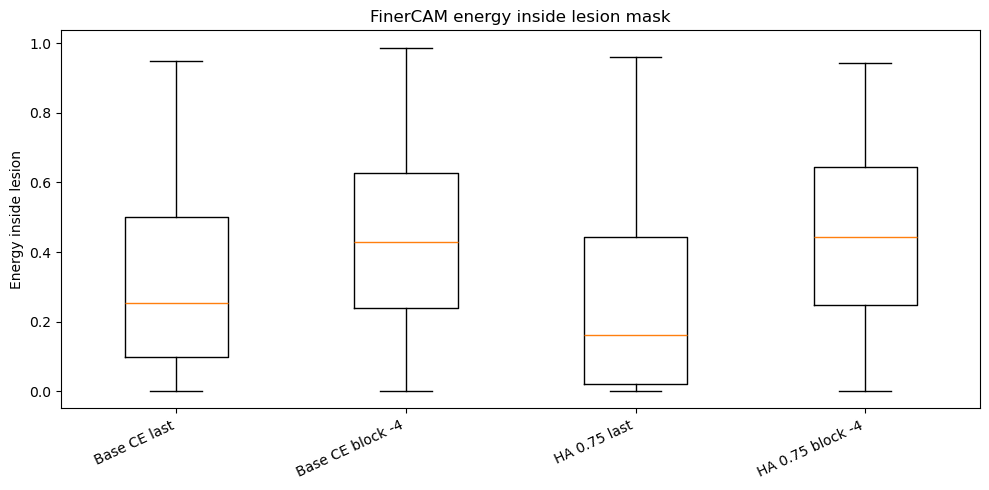

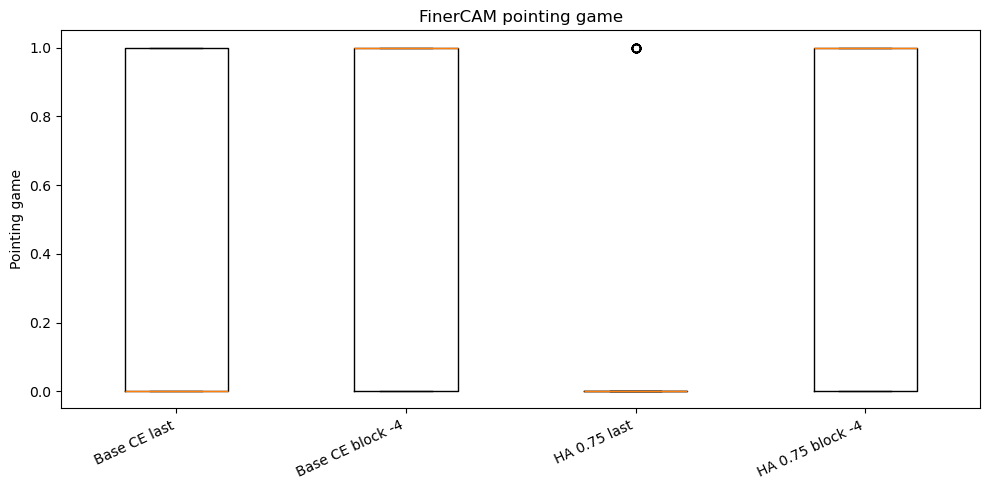

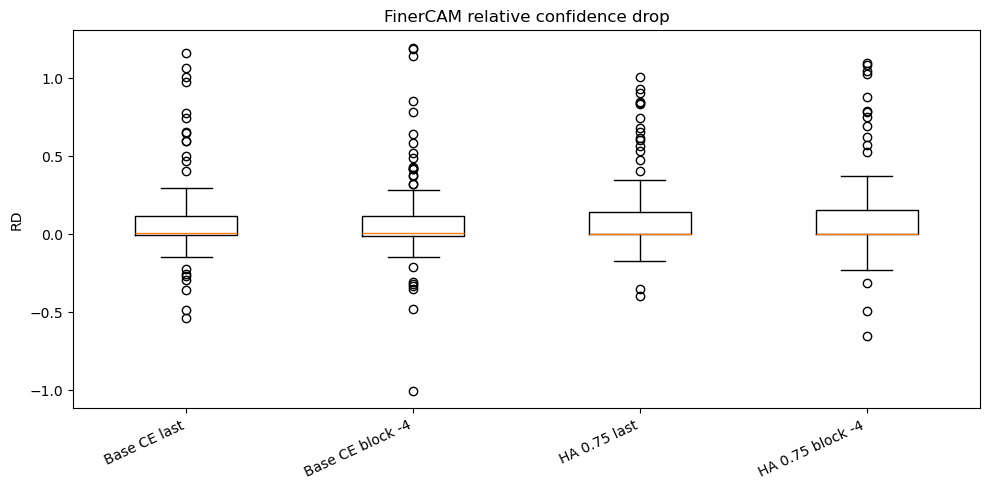

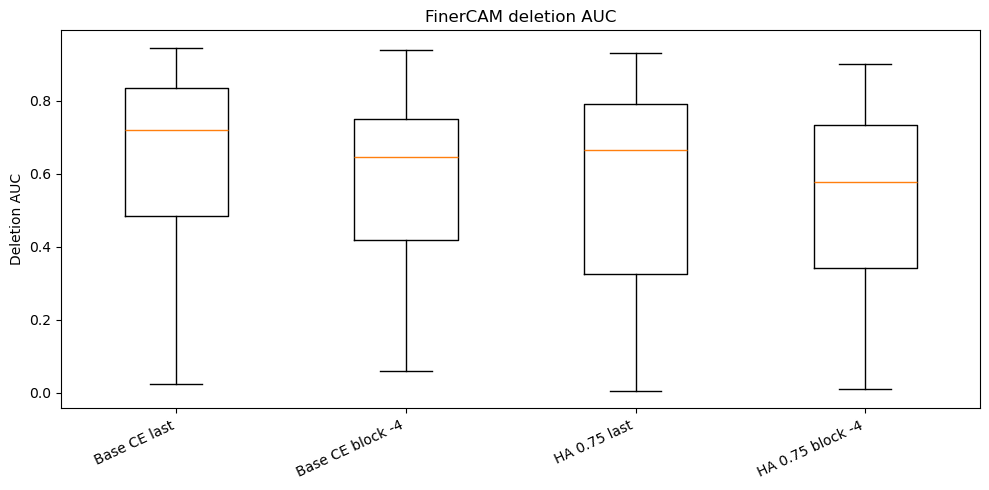

In [8]:
def plot_finercam_metric(metric_col, title, ylabel):
    if metric_col not in all_per_sample.columns:
        print(f"Missing metric: {metric_col}")
        return

    sub = all_per_sample[all_per_sample["method"].astype(str) == "finercam"].copy()

    order = [
        "Base CE last",
        "Base CE block -4",
        "HA 0.75 last",
        "HA 0.75 block -4",
    ]

    data = []
    labels = []

    for exp in order:
        vals = sub[sub["experiment"].astype(str) == exp][metric_col].dropna().values
        if len(vals) > 0:
            data.append(vals)
            labels.append(exp)

    plt.figure(figsize=(10, 5))
    plt.boxplot(data, tick_labels=labels)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


plot_finercam_metric(
    metric_col="mask_energy_inside",
    title="FinerCAM energy inside lesion mask",
    ylabel="Energy inside lesion",
)

plot_finercam_metric(
    metric_col="mask_pointing_game",
    title="FinerCAM pointing game",
    ylabel="Pointing game",
)

plot_finercam_metric(
    metric_col="rel_conf_average_relative_confidence_drop",
    title="FinerCAM relative confidence drop",
    ylabel="RD",
)

plot_finercam_metric(
    metric_col="del_auc",
    title="FinerCAM deletion AUC",
    ylabel="Deletion AUC",
)

In [ ]:
# OUT_DIR = REPO_ROOT / "outputs" / f"cam_metrics_base_vs_ha_blocks_seed{QUAL_SEED}"
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# all_per_sample_out = OUT_DIR / f"per_sample_all_base_vs_ha_blocks_seed{QUAL_SEED}.csv"
# compact_summary_out = OUT_DIR / f"compact_summary_base_vs_ha_blocks_seed{QUAL_SEED}.csv"
# main_table_out = OUT_DIR / f"main_table_base_vs_ha_blocks_seed{QUAL_SEED}.csv"
# finercam_table_out = OUT_DIR / f"finercam_table_base_vs_ha_blocks_seed{QUAL_SEED}.csv"
# block_delta_out = OUT_DIR / f"block_delta_finercam_seed{QUAL_SEED}.csv"

# all_per_sample.to_csv(all_per_sample_out, index=False)
# compact_summary.to_csv(compact_summary_out, index=False)
# main_table.to_csv(main_table_out, index=False)
# finercam_table.to_csv(finercam_table_out, index=False)
# block_delta.to_csv(block_delta_out, index=False)

# print("Saved:")
# print(all_per_sample_out)
# print(compact_summary_out)
# print(main_table_out)
# print(finercam_table_out)
# print(block_delta_out)

Saved:
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/cam_metrics_base_vs_ha_blocks_seed42/per_sample_all_base_vs_ha_blocks_seed42.csv
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/cam_metrics_base_vs_ha_blocks_seed42/compact_summary_base_vs_ha_blocks_seed42.csv
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/cam_metrics_base_vs_ha_blocks_seed42/main_table_base_vs_ha_blocks_seed42.csv
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/cam_metrics_base_vs_ha_blocks_seed42/finercam_table_base_vs_ha_blocks_seed42.csv
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/cam_metrics_base_vs_ha_blocks_seed42/block_delta_finercam_seed42.csv
